# Fig: convergence & rate-distortion

project = ```iP-VAE```, host = ```mach```, device = ```cuda:1```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

## Results & Figs dir

In [3]:
pal_models = get_palette_models()

results_dir = pjoin(tmp_dir, 'results_2025-03')
figs_dir = pjoin(fig_base_dir, 'results_2025-03')

os.makedirs(results_dir, exist_ok=True)
os.makedirs(figs_dir, exist_ok=True)

len(os.listdir(results_dir)), len(os.listdir(figs_dir))

(354, 0)

## Rate-Distortion fig

In [4]:
files = [f for f in os.listdir(results_dir) if 'vH16' in f]
files = sorted(files, key=alphanum_sort_key)

len(files)

144

In [5]:
info_keys = [
    'type', 'latent_act', 'model_str',
    'seq_len', 'kl_beta',
]

df_ratedist = collections.defaultdict(list)
for f in tqdm(files):
    if 'softplus' in f:
        continue

    load = np.load(pjoin(results_dir, f), allow_pickle=True).item()
    info, results = load['info'], load['results']

    if 'softplus' in info['model_str']:
        continue

    # info
    for k in info_keys:
        df_ratedist[k].append(info.get(k, None))
    df_ratedist['amort'].append('amort' in f)

    # results
    try:
        r2 = results['r2'][-1]
        percent_zeros = results['%-zeros'][-1]
    except TypeError:
        r2 = results['r2']
        percent_zeros = results['%-zeros']
    distance = np.sqrt((1 - r2)**2 + (1 - percent_zeros)**2)

    df_ratedist['%-zeros'].append(percent_zeros)
    df_ratedist['r2'].append(r2)
    df_ratedist['r2_map'].append(results.get('r2_map_final', None))
    df_ratedist['distance'].append(distance)

df_ratedist = pd.DataFrame(df_ratedist)
df_ratedist.shape

100%|█████████████████████████████████████████| 144/144 [00:05<00:00, 25.78it/s]


(108, 10)

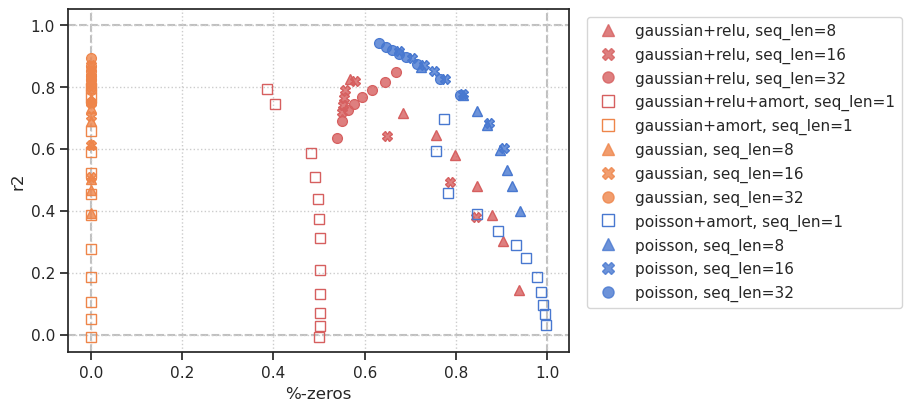

In [6]:
from figures.final import fig_ratedist_scatter

fig = fig_ratedist_scatter(df_ratedist)

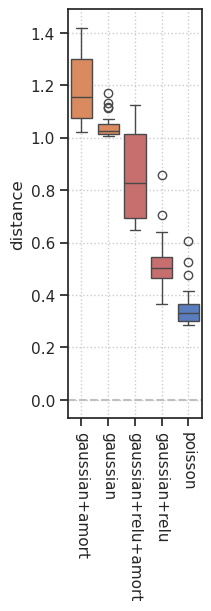

In [7]:
fig, ax = create_figure(1, 1, (2, 6))
sns.boxplot(
    data=df_ratedist,
    x='model_str',
    y='distance',
    order=['gaussian+amort', 'gaussian', 'gaussian+relu+amort', 'gaussian+relu', 'poisson'],
    palette=pal_models,
    hue='model_str',
    ax=ax,
)
ax.axhline(0, ls='--', color='silver')
ax.tick_params(axis='x', rotation=-90)
ax.set(xlabel='')
add_grid(ax)
plt.show()

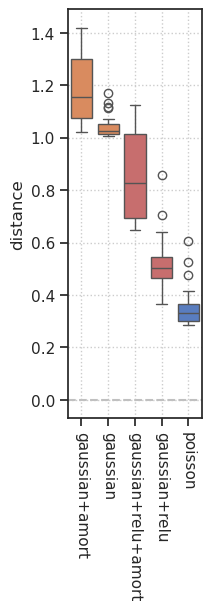

In [16]:
fig, ax = create_figure(1, 1, (2, 6))
sns.boxplot(
    data=df_ratedist.loc[df_ratedist['latent_act'] != 'softplus'],
    x='model_str',
    y='distance',
    order=['gaussian+amort', 'gaussian', 'gaussian+relu+amort', 'gaussian+relu', 'poisson'],
    palette=pal_models,
    hue='model_str',
    ax=ax,
)
ax.axhline(0, ls='--', color='silver')
ax.tick_params(axis='x', rotation=-90)
ax.set(xlabel='')
add_grid(ax)
plt.show()

In [9]:
_df = df_ratedist.loc[
    (df_ratedist['seq_len'] == 16) &
    (df_ratedist['latent_act'] != 'softplus')
]
_df = _df.sort_values(by='distance', ascending=True)

In [10]:
_df

,type,latent_act,model_str,seq_len,kl_beta,amort,%-zeros,r2,r2_map,distance
132,poisson,None,poisson,16,24.0,False,7.750223e-01,0.826882,0.916790,0.283875
131,poisson,None,poisson,16,20.0,False,7.526429e-01,0.850000,0.931343,0.289284
133,poisson,None,poisson,16,32.0,False,8.159058e-01,0.776233,0.879043,0.289763
130,poisson,None,poisson,16,16.0,False,7.290817e-01,0.872029,0.943479,0.299622
129,poisson,None,poisson,16,12.0,False,7.038352e-01,0.893830,0.953737,0.314620
128,poisson,None,poisson,16,8.0,False,6.751572e-01,0.915614,0.962413,0.335625
134,poisson,None,poisson,16,48.0,False,8.725250e-01,0.682278,0.799042,0.342341
135,poisson,None,poisson,16,64.0,False,9.054468e-01,0.602744,0.725726,0.408353
8,gaussian,relu,gaussian+relu,16,8.0,False,5.775826e-01,0.819666,0.893119,0.459300
9,gaussian,relu,gaussian+relu,16,12.0,False,5.572358e-01,0.789112,0.902145,0.490422


In [11]:
seq_tot = 1000

info_keys = ['type', 'latent_act', 'model_str', 'seq_len', 'kl_beta']
results_keys = ['r2', '%-zeros', 'du_norm']

df_convergence = collections.defaultdict(list)
for f in files:
    cond_skip = (
        'softplus' in f or
        't-16' not in f or
        'amort' in f
    )
    if cond_skip:
        continue
    # if f"t-16_b-24" not in f:
    #     continue
    load = np.load(pjoin(results_dir, f), allow_pickle=True).item()
    info, results = load['info'], load['results']
    
    # info
    for k in info_keys:
        df_convergence[k].extend([info[k]] * seq_tot)
    df_convergence['time'].extend(range(seq_tot))
    
    # results
    for k in results_keys:
        df_convergence[k].extend(results[k])

df_convergence = pd.DataFrame(df_convergence)
df_convergence.shape

(24000, 9)

In [12]:
df_convergence

,type,latent_act,model_str,seq_len,kl_beta,time,r2,%-zeros,du_norm
0,gaussian,relu,gaussian+relu,16,8.0,0,0.147592,0.066867,4.380859
1,gaussian,relu,gaussian+relu,16,8.0,1,0.341152,0.085178,3.659226
2,gaussian,relu,gaussian+relu,16,8.0,2,0.464746,0.104548,3.063977
3,gaussian,relu,gaussian+relu,16,8.0,3,0.547927,0.122689,2.623281
4,gaussian,relu,gaussian+relu,16,8.0,4,0.604529,0.139034,2.306428
...,...,...,...,...,...,...,...,...,...
23995,poisson,None,poisson,16,64.0,995,0.603049,0.905427,0.512628
23996,poisson,None,poisson,16,64.0,996,0.602943,0.905430,0.512113
23997,poisson,None,poisson,16,64.0,997,0.603210,0.905500,0.512319
23998,poisson,None,poisson,16,64.0,998,0.602777,0.905494,0.512895


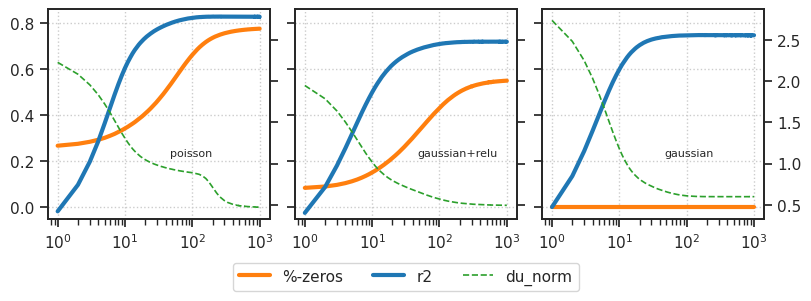

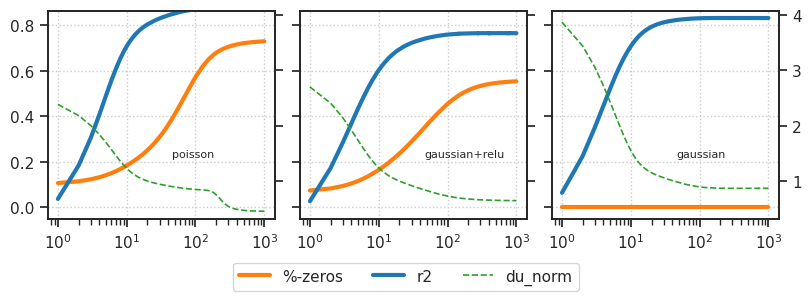

In [19]:
from figures.final import fig_convergence
fig = fig_convergence(df_convergence, 16, 24)
fig = fig_convergence(df_convergence, 16, 16)

In [42]:
t, b = 16, 24

selected_df = df_convergence.loc[
    (df_convergence['seq_len'] == t) & 
    (df_convergence['kl_beta'] == b)
]

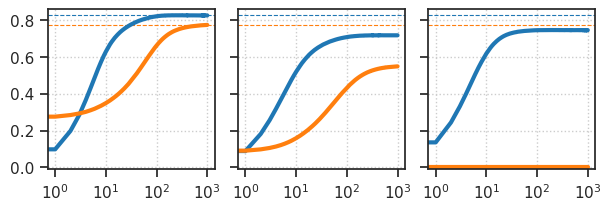

In [92]:
_df_poisson = selected_df.loc[selected_df['model_str'] == 'poisson']
poisson_percent_zeros = _df_poisson['%-zeros'].values[-1]
poisson_r2 = _df_poisson['r2'].values[-1]

fig, axes = create_figure(1, 3, (6, 2), sharey='all')
for i, model in enumerate(['poisson', 'gaussian+relu', 'gaussian']):
    _df = selected_df.loc[selected_df['model_str'] == model]
    ax = axes[i]
    ax.axhline(poisson_r2, color='C0', ls='--', lw=0.8)
    ax.axhline(poisson_percent_zeros, color='C1', ls='--', lw=0.8)
    
    ax.plot(_df['r2'].values, color='C0', lw=3)
    ax.plot(_df['%-zeros'].values, color='C1', lw=3)
    ax.set(xscale='log', ylim=(-0.01, 0.86))
    ax.xaxis.set_major_locator(matplotlib.ticker.LogLocator(
        base=10.0, subs=[1.0], numticks=4))

add_grid(axes)
plt.show()

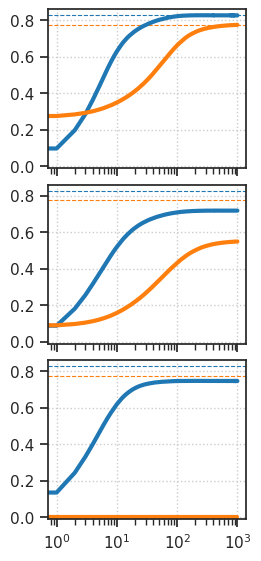

In [100]:
_df_poisson = selected_df.loc[selected_df['model_str'] == 'poisson']
poisson_percent_zeros = _df_poisson['%-zeros'].values[-1]
poisson_r2 = _df_poisson['r2'].values[-1]

fig, axes = create_figure(3, 1, (2.5, 5.5), sharex='all', sharey='all')
for i, model in enumerate(['poisson', 'gaussian+relu', 'gaussian']):
    _df = selected_df.loc[selected_df['model_str'] == model]
    ax = axes[i]
    ax.axhline(poisson_r2, color='C0', ls='--', lw=0.8)
    ax.axhline(poisson_percent_zeros, color='C1', ls='--', lw=0.8)
    
    ax.plot(_df['r2'].values, color='C0', lw=3)
    ax.plot(_df['%-zeros'].values, color='C1', lw=3)
    ax.set(xscale='log', ylim=(-0.01, 0.86))
    # ax.xaxis.set_major_locator(matplotlib.ticker.LogLocator(
    #     base=10.0, subs=[1.0], numticks=4))

add_grid(axes)
plt.show()

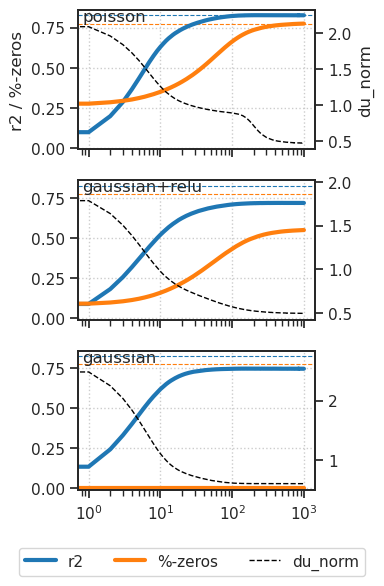

In [110]:
df_poisson = selected_df.loc[selected_df['model_str'] == 'poisson']
poisson_percent_zeros = df_poisson['%-zeros'].values[-1]
poisson_r2 = df_poisson['r2'].values[-1]

fig, axes = create_figure(3, 1, (4, 5.5), sharex='all')  # Removed sharey='all'

# Keep track of the twin axes
right_axes = []

for i, model in enumerate(['poisson', 'gaussian+relu', 'gaussian']):
    df = selected_df.loc[selected_df['model_str'] == model]
    ax = axes[i]
    
    # Create a twin axis and save reference
    ax_right = ax.twinx()
    right_axes.append(ax_right)

    # New plot on right y-axis with corrected key
    ax_right.plot(df['du_norm'].values, color='k', lw=1, ls='--', label='du_norm')
    
    # Original plots on left y-axis
    ax.axhline(poisson_r2, color='C0', ls='--', lw=0.8)
    ax.axhline(poisson_percent_zeros, color='C1', ls='--', lw=0.8)
    ax.plot(df['r2'].values, color='C0', lw=3, label='r2')
    ax.plot(df['%-zeros'].values, color='C1', lw=3, label='%-zeros')
    
    # Set scales and limits
    ax.set(xscale='log', ylim=(-0.01, 0.86))
    
    # You may need to adjust the right y-axis limits based on your data
    # ax_right.set_ylim([min_val, max_val])
    
    # Add labels
    if i == 0:
        ax.set_ylabel('r2 / %-zeros')
        ax_right.set_ylabel('du_norm')
    
    # Add model name
    ax.text(0.02, 0.92, model, transform=ax.transAxes)

add_grid(axes)

# Add a legend with correct references
lines_left, labels_left = axes[0].get_legend_handles_labels()
lines_right, labels_right = right_axes[0].get_legend_handles_labels()
lines = lines_left + lines_right
labels = labels_left + labels_right
fig.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 0), ncol=3)

plt.tight_layout()
plt.show()

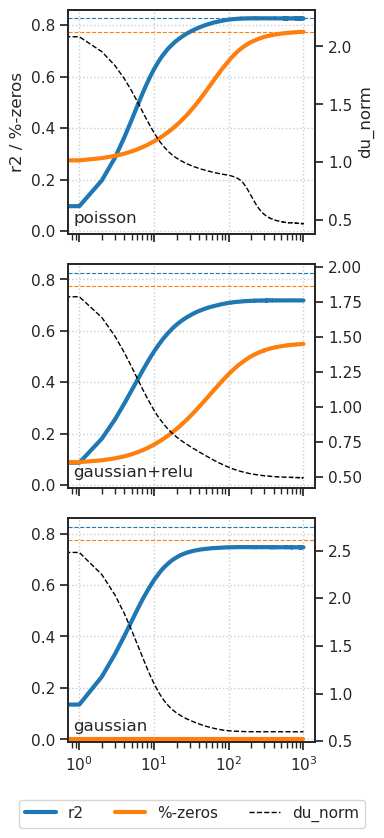

In [117]:
df_poisson = selected_df.loc[selected_df['model_str'] == 'poisson']
poisson_percent_zeros = df_poisson['%-zeros'].values[-1]
poisson_r2 = df_poisson['r2'].values[-1]
fig, axes = create_figure(3, 1, (4, 8.0), sharex='all')  # Removed sharey='all'

# Keep track of the twin axes
right_axes = []

for i, model in enumerate(['poisson', 'gaussian+relu', 'gaussian']):
    df = selected_df.loc[selected_df['model_str'] == model]
    ax = axes[i]
    
    # Create a twin axis and save reference
    ax_right = ax.twinx()
    right_axes.append(ax_right)
    
    # New plot on right y-axis with corrected key - use zorder to force it to the background
    du_norm_line = ax_right.plot(df['du_norm'].values, color='k', lw=1, ls='--', label='du_norm', zorder=1)
    
    # Original plots on left y-axis with higher zorder values
    ax.axhline(poisson_r2, color='C0', ls='--', lw=0.8, zorder=2)
    ax.axhline(poisson_percent_zeros, color='C1', ls='--', lw=0.8, zorder=2)
    r2_line = ax.plot(df['r2'].values, color='C0', lw=3, label='r2', zorder=3)
    zeros_line = ax.plot(df['%-zeros'].values, color='C1', lw=3, label='%-zeros', zorder=4)
    
    # Set scales and limits
    ax.set(xscale='log', ylim=(-0.01, 0.86))
    
    # You may need to adjust the right y-axis limits based on your data
    # ax_right.set_ylim([min_val, max_val])
    
    # Add labels
    if i == 0:
        ax.set_ylabel('r2 / %-zeros')
        ax_right.set_ylabel('du_norm')
    
    # Add model name
    ax.text(0.02, 0.05, model, transform=ax.transAxes, zorder=5)  # Text on top

add_grid(axes)

# Add a legend with correct references
lines_left, labels_left = axes[0].get_legend_handles_labels()
lines_right, labels_right = right_axes[0].get_legend_handles_labels()
lines = lines_left + lines_right
labels = labels_left + labels_right
fig.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 0), ncol=3)

plt.tight_layout()
plt.show()

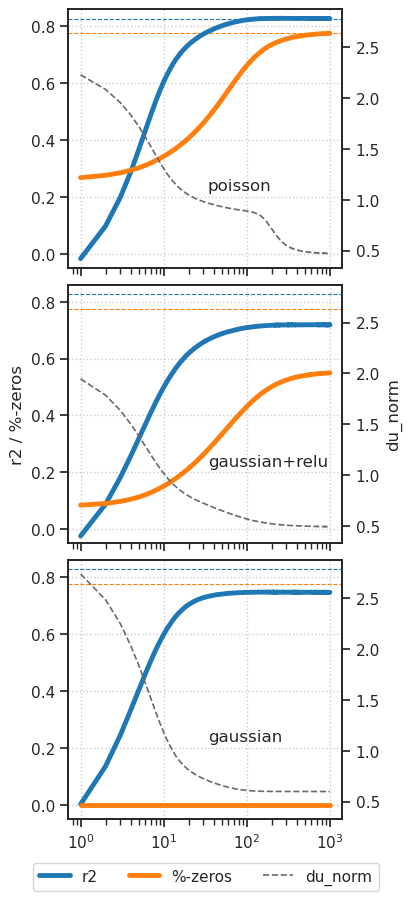

In [153]:
df_poisson = selected_df.loc[selected_df['model_str'] == 'poisson']
poisson_percent_zeros = df_poisson['%-zeros'].values[-1]
poisson_r2 = df_poisson['r2'].values[-1]
fig, axes = create_figure(3, 1, (4, 8.5), sharex='all')  # Removed sharey='all'

# Keep track of the twin axes
right_axes = []

# First collect all du_norm values to determine consistent y-axis limits
all_du_norm_values = []
for model in ['poisson', 'gaussian+relu', 'gaussian']:
    df = selected_df.loc[selected_df['model_str'] == model]
    all_du_norm_values.extend(df['du_norm'].values)

# Calculate right y-axis limits
du_norm_min = min(all_du_norm_values)
du_norm_max = max(all_du_norm_values)

# For log scale, ensure minimum value is positive and curve stays within view
if du_norm_min <= 0:
    # Find the smallest positive value
    positive_values = [v for v in all_du_norm_values if v > 0]
    if positive_values:
        du_norm_min = min(positive_values) * 0.9  # Set minimum just below the smallest value
    else:
        du_norm_min = 0.001  # Fallback if no positive values
else:
    # If already positive, still apply a small buffer to ensure visibility
    du_norm_min *= 0.7

# Set upper limit with small buffer
du_norm_max *= 1.05

xs = np.arange(1, 1000 + 1)
for i, model in enumerate(['poisson', 'gaussian+relu', 'gaussian']):
    df = selected_df.loc[selected_df['model_str'] == model]
    ax = axes[i]
    
    # Create a twin axis and save reference
    ax_right = ax.twinx()
    right_axes.append(ax_right)
    
    # Set right y-axis to log scale
    ax_right.set_yscale('linear')
    
    # New plot on right y-axis
    du_norm_line = ax_right.plot(xs, df['du_norm'].values, color='dimgrey', lw=1.2, ls='--', label='du_norm', zorder=1)
    
    # Set limits to ensure curve is visible
    ax_right.set_ylim(du_norm_min, du_norm_max)
    
    # Original plots on left y-axis
    ax.axhline(poisson_r2, color='C0', ls='--', lw=0.8, zorder=2)
    ax.axhline(poisson_percent_zeros, color='C1', ls='--', lw=0.8, zorder=2)
    r2_line = ax.plot(xs, df['r2'].values, color='C0', lw=3.5, label='r2', zorder=3)
    zeros_line = ax.plot(xs, df['%-zeros'].values, color='C1', lw=3.5, label='%-zeros', zorder=4)
    
    # Set scales and limits for left y-axis
    ax.set(xscale='log', ylim=(-0.05, 0.86))
    
    # Add labels
    if i == 1:
        ax.set_ylabel('r2 / %-zeros')
        ax_right.set_ylabel('du_norm')
    
    # Add model name
    ax.text(0.51, 0.3, model, transform=ax.transAxes, zorder=5)

add_grid(axes)

# Add a legend with correct references
lines_left, labels_left = axes[0].get_legend_handles_labels()
lines_right, labels_right = right_axes[0].get_legend_handles_labels()
lines = lines_left + lines_right
labels = labels_left + labels_right
fig.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 0), ncol=3)

plt.show()

[None, None]

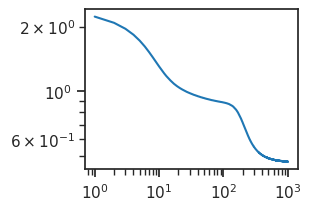

In [140]:
fig, ax = create_figure()
ax.plot(xs, df_poisson['du_norm'].values)
ax.set(xscale='log', yscale='log')

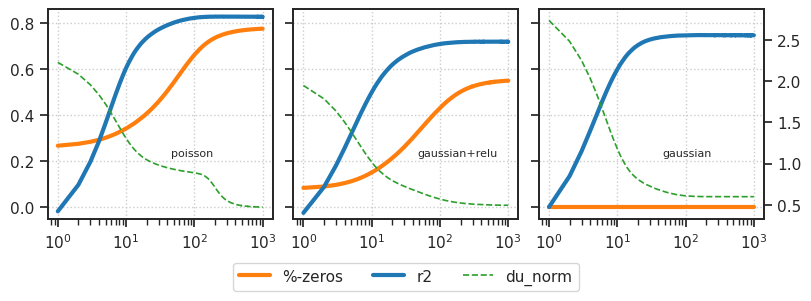

In [208]:
df_poisson = selected_df.loc[selected_df['model_str'] == 'poisson']
poisson_percent_zeros = df_poisson['%-zeros'].values[-1]
poisson_r2 = df_poisson['r2'].values[-1]
fig, axes = create_figure(1, 3, (8, 2.5), sharex='all', sharey='all')

# Keep track of the twin axes
right_axes = []

# First collect all du_norm values to determine consistent y-axis limits
all_du_norm_values = []
for model in ['poisson', 'gaussian+relu', 'gaussian']:
    df = selected_df.loc[selected_df['model_str'] == model]
    all_du_norm_values.extend(df['du_norm'].values)

# Calculate right y-axis limits
du_norm_min = min(all_du_norm_values)
du_norm_max = max(all_du_norm_values)

# For log scale, ensure minimum value is positive and curve stays within view
if du_norm_min <= 0:
    # Find the smallest positive value
    positive_values = [v for v in all_du_norm_values if v > 0]
    if positive_values:
        du_norm_min = min(positive_values) * 0.9  # Set minimum just below the smallest value
    else:
        du_norm_min = 0.001  # Fallback if no positive values
else:
    # If already positive, still apply a small buffer to ensure visibility
    du_norm_min *= 0.7

# Set upper limit with small buffer
du_norm_max *= 1.05

xs = np.arange(1, 1000 + 1)
for i, model in enumerate(['poisson', 'gaussian+relu', 'gaussian']):
    df = selected_df.loc[selected_df['model_str'] == model]
    ax = axes[i]
    
    # Create a twin axis and save reference
    ax_right = ax.twinx()
    right_axes.append(ax_right)
    
    # Set right y-axis to linear scale
    ax_right.set_yscale('linear')
    
    # New plot on right y-axis
    du_norm_line = ax_right.plot(xs, df['du_norm'].values, color='C2', lw=1.2, ls='--', label='du_norm', zorder=1)
    
    # Set limits to ensure curve is visible
    ax_right.set_ylim(du_norm_min, du_norm_max)
    
    if i < 2:
        ax_right.set(yticks=[], yticklabels=[])

    # Original plots on left y-axis
    # ax.axhline(poisson_percent_zeros, color='firebrick', ls='--', lw=0.8, zorder=2)
    # ax.axhline(poisson_r2, color='slateblue', ls='--', lw=0.8, zorder=2)
    zeros_line = ax.plot(xs, df['%-zeros'].values, color='C1', lw=3., label='%-zeros', zorder=3)
    r2_line = ax.plot(xs, df['r2'].values, color='C0', lw=3., label='r2', zorder=4)
    
    # Set scales and limits for left y-axis
    ax.set(xscale='log', ylim=(-0.05, 0.86))
    
    # Add model name
    ax.text(0.55, 0.3, model, transform=ax.transAxes, fontsize=8, zorder=5)

add_grid(axes)

# Add a legend with correct references
lines_left, labels_left = axes[0].get_legend_handles_labels()
lines_right, labels_right = right_axes[0].get_legend_handles_labels()
lines = lines_left + lines_right
labels = labels_left + labels_right
fig.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 0), ncol=3)

plt.show()

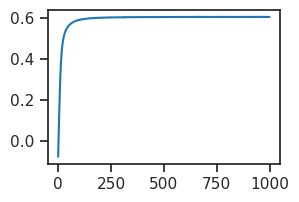

In [22]:
plot(results['r2'])

In [26]:
pal_models = get_palette_models()
markers = {1: '.', 8: 'D', 16: 'o', 32: 's'}

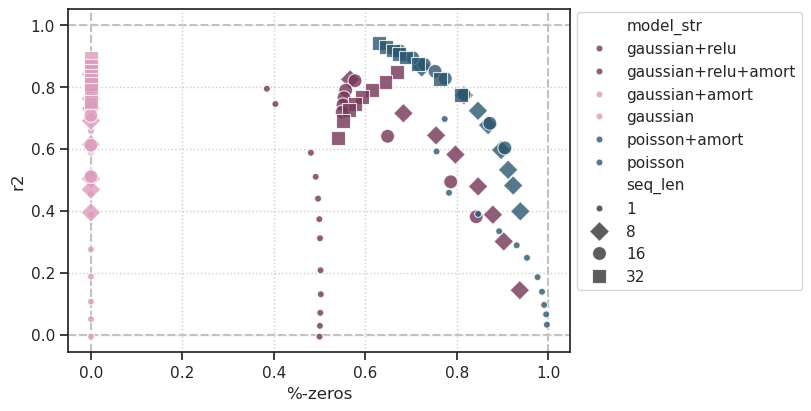

In [27]:
fig, ax = create_figure(1, 1, (8, 4))

_df = df.loc[df['latent_act'] != 'softplus']

sns.scatterplot(
    data=_df,
    x='%-zeros',
    y='r2',
    palette=pal_models,
    hue='model_str',
    style='seq_len',
    markers=markers,
    s=100,
    alpha=0.8,
    ax=ax,
    # fillstyle=['none', 'full', 'full', 'full']  # Controls which markers are filled
)
ax.axvline(0, color='silver', ls='--', zorder=0)
ax.axvline(1, color='silver', ls='--', zorder=0)
ax.axhline(0, color='silver', ls='--', zorder=0)
ax.axhline(1, color='silver', ls='--', zorder=0)
move_legend(ax, (1.0, 1.015))
add_grid(ax)
# ax_square(ax)
plt.show()

In [68]:
def get_palette_models():
	kws_1 = dict(start=2.6, rot=0.03, light=0.7, dark=0.3)
	kws_2 = dict(start=0.6, rot=0.03, light=0.7, dark=0.3)
	cube_1 = get_cubehelix_palette(n_colors=3, **kws_1)
	cube_2 = get_cubehelix_palette(n_colors=3, **kws_2)
	pal_models = {
		'poisson': cube_1[-1],
		'poisson+amort': cube_1[-1],
		'gaussian': cube_2[0],
		'gaussian+amort': cube_2[0],
		'gaussian+relu': cube_2[2],
		'gaussian+relu+amort': cube_2[2],
		'gaussian+softplus': cube_2[1],
		'gaussian+softplus+amort': cube_2[1],
	}
	return pal_models

In [69]:
pal_models = get_palette_models()

Text(0, 0.5, 'r2')

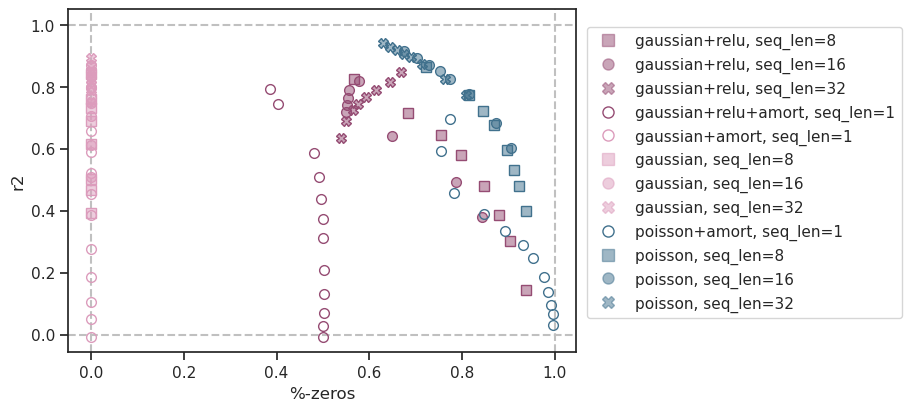

In [81]:
def get_palette_models():
	kws_1 = dict(start=2.6, rot=0.03, light=0.7, dark=0.3)
	kws_2 = dict(start=0.6, rot=0.03, light=0.7, dark=0.3)
	cube_1 = get_cubehelix_palette(n_colors=5, **kws_1)
	cube_2 = get_cubehelix_palette(n_colors=5, **kws_2)
	pal_models = {
		'poisson': cube_1[-2],
		'poisson+amort': cube_1[-2],
		'gaussian': cube_2[0],
		'gaussian+amort': cube_2[0],
		'gaussian+relu': cube_2[-2],
		'gaussian+relu+amort': cube_2[-2],
		'gaussian+softplus': cube_2[1],
		'gaussian+softplus+amort': cube_2[1],
	}
	return pal_models

In [82]:
pal_models = get_palette_models()

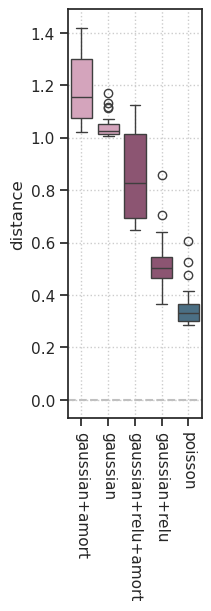

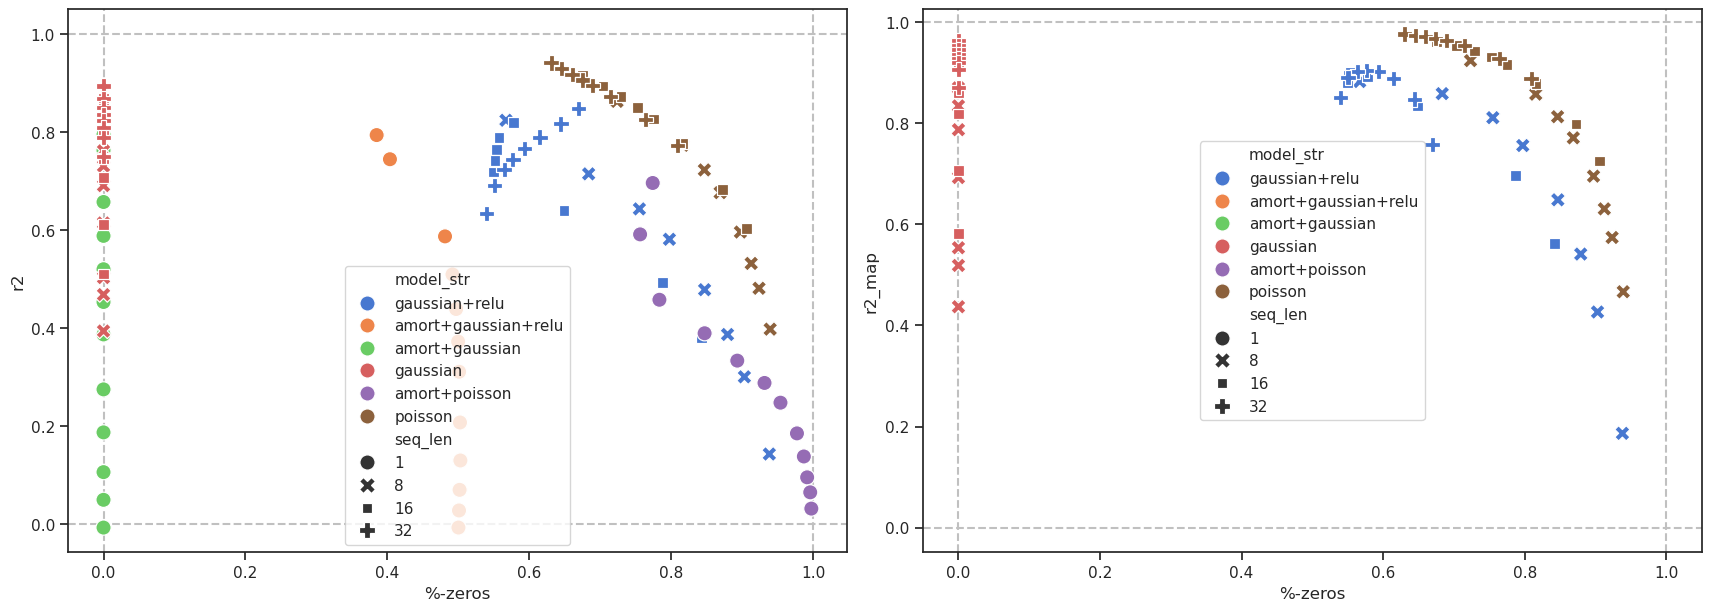

In [7]:
fig, axes = create_figure(1, 2, (17, 6))

_df = df.loc[df['latent_act'] != 'softplus']

sns.scatterplot(
    data=_df,
    x='%-zeros',
    y='r2',
    palette='muted', # pal_models,
    hue='model_str',
    style='seq_len',
    s=120,
    ax=axes[0],
)
sns.scatterplot(
    data=_df,
    x='%-zeros',
    y='r2_map',
    palette='muted',  # pal_models,
    hue='model_str',
    style='seq_len',
    s=120,
    ax=axes[1],
)

for ax in axes.flat:
    ax.axvline(0, color='silver', ls='--', zorder=0)
    ax.axvline(1, color='silver', ls='--', zorder=0)
    ax.axhline(0, color='silver', ls='--', zorder=0)
    ax.axhline(1, color='silver', ls='--', zorder=0)
# ax_square(ax)
plt.show()

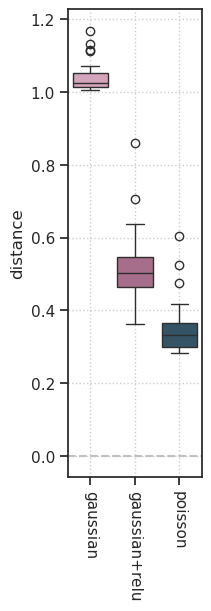

In [11]:
fig, ax = create_figure(1, 1, (2, 6))
sns.boxplot(
    data=df,
    x='model_str',
    y='distance',
    order=['gaussian', 'gaussian+relu', 'poisson'],
    palette=pla_models,
    hue='model_str',
    ax=ax,
)
ax.axhline(0, ls='--', color='silver')
ax.tick_params(axis='x', rotation=-90)
ax.set(xlabel='')
add_grid(ax)
plt.show()

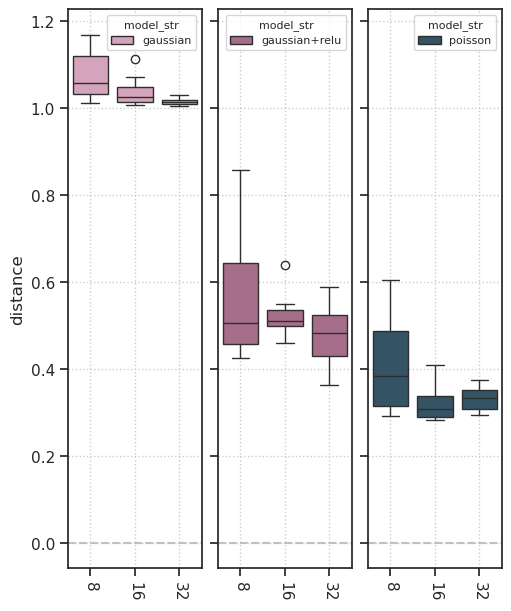

In [22]:
fig, axes = create_figure(1, 3, (5, 6), sharey='all')
for i, model_str in enumerate(['gaussian', 'gaussian+relu', 'poisson']):
    ax = axes[i]
    sns.boxplot(
        data=df.loc[df['model_str'] == model_str],
        x=translate['seq_len'],
        y='distance',
        # order=['gaussian', 'gaussian+relu', 'poisson'],
        palette=pla_models,
        hue='model_str',
        ax=ax,
    )
    sns.move_legend(ax, loc='best', fontsize=8, title_fontsize=8)
    ax.axhline(0, ls='--', color='silver')
    ax.tick_params(axis='x', rotation=-90)
    ax.set(xlabel='')
add_grid(axes)
plt.show()

In [49]:
_df

,type,latent_act,model_str,$T_\text{train}$,kl_beta,%-zeros,$R^2$,r2_map,distance
84,poisson,None,poisson,16,24.0,7.750223e-01,0.826882,0.916790,0.283875
83,poisson,None,poisson,16,20.0,7.526429e-01,0.850000,0.931343,0.289284
85,poisson,None,poisson,16,32.0,8.159058e-01,0.776233,0.879043,0.289763
82,poisson,None,poisson,16,16.0,7.290817e-01,0.872029,0.943479,0.299622
81,poisson,None,poisson,16,12.0,7.038352e-01,0.893830,0.953737,0.314620
80,poisson,None,poisson,16,8.0,6.751572e-01,0.915614,0.962413,0.335625
86,poisson,None,poisson,16,48.0,8.725250e-01,0.682278,0.799042,0.342341
87,poisson,None,poisson,16,64.0,9.054468e-01,0.602744,0.725726,0.408353
56,gaussian,None,gaussian,16,8.0,0.000000e+00,0.869541,0.960710,1.008474
57,gaussian,None,gaussian,16,12.0,0.000000e+00,0.849192,0.949945,1.011308
